In [10]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

In [11]:
data = pd.read_csv("../data/processed/electricity_features.csv")
data["timestamp"] = pd.to_datetime(data["timestamp"], utc=True)

data.head()

,timestamp,load,period,hour,day_of_week,month,is_weekend,season,season_encoded,lag_1,lag_24,lag_168,rolling_mean_24
0,2018-01-07 23:00:00+00:00,15993.19,calm,23,6,1,1,winter,0,16836.21,15330.00,14978.54,17287.211250
1,2018-01-08 00:00:00+00:00,15633.59,calm,0,0,1,0,winter,0,15993.19,14662.44,14397.65,17327.675833
2,2018-01-08 01:00:00+00:00,15462.54,calm,1,0,1,0,winter,0,15633.59,14367.65,13789.46,17373.296250
3,2018-01-08 02:00:00+00:00,15445.81,calm,2,0,1,0,winter,0,15462.54,14295.76,13434.45,17421.215000
4,2018-01-08 03:00:00+00:00,15892.14,calm,3,0,1,0,winter,0,15445.81,14252.75,13285.24,17489.522917


In [12]:
print("Shape:", data.shape)
print("Columns:")
print(data.columns.tolist())

Shape: (52415, 13)
Columns:
['timestamp', 'load', 'period', 'hour', 'day_of_week', 'month', 'is_weekend', 'season', 'season_encoded', 'lag_1', 'lag_24', 'lag_168', 'rolling_mean_24']


In [13]:
feature_cols = [
    "hour",
    "day_of_week",
    "month",
    "season_encoded",
    "is_weekend",
    "lag_1",
    "lag_24",
    "lag_168",
    "rolling_mean_24"
]

target_col = "load"

X = data[feature_cols]
y = data[target_col]

In [14]:
split_index = int(len(data) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

test_meta = data.iloc[split_index:][["timestamp", "period"]].copy()

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (41932, 9)
Test size: (10483, 9)


In [15]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

In [16]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [17]:
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

In [18]:
gb_model = GradientBoostingRegressor(random_state=42)
gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

In [19]:
def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    return {
        "model": model_name,
        "MAE": mae,
        "RMSE": rmse
    }

In [20]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
knn_model = KNeighborsRegressor()
knn_model.fit(X_train_scaled, y_train)

knn_pred = knn_model.predict(X_test_scaled)

In [22]:
svr_model = SVR()
svr_model.fit(X_train_scaled, y_train)

svr_pred = svr_model.predict(X_test_scaled)

In [23]:
results = []

results.append(evaluate_model(y_test, lr_pred, "Linear Regression"))
results.append(evaluate_model(y_test, rf_pred, "Random Forest"))
results.append(evaluate_model(y_test, dt_pred, "Decision Tree"))
results.append(evaluate_model(y_test, gb_pred, "Gradient Boosting"))
results.append(evaluate_model(y_test, knn_pred, "KNN"))
results.append(evaluate_model(y_test, svr_pred, "SVR"))

results_df = pd.DataFrame(results)
results_df

,model,MAE,RMSE
0,Linear Regression,447.589685,601.166775
1,Random Forest,191.848917,267.375296
2,Decision Tree,262.140358,373.397585
3,Gradient Boosting,275.384758,365.149497
4,KNN,331.375197,464.985273
5,SVR,1264.817090,1748.059125


In [24]:
predictions_df = test_meta.copy()
predictions_df["actual_load"] = y_test.values
predictions_df["lr_pred"] = lr_pred
predictions_df["rf_pred"] = rf_pred
predictions_df["dt_pred"] = dt_pred
predictions_df["gb_pred"] = gb_pred
predictions_df["knn_pred"] = knn_pred
predictions_df["svr_pred"] = svr_pred

predictions_df.head()

,timestamp,period,actual_load,lr_pred,rf_pred,dt_pred,gb_pred,knn_pred,svr_pred
41932,2022-10-21 04:00:00+00:00,war,20270.54,18566.822745,20336.8420,20436.40,19900.673626,20229.774,19362.202311
41933,2022-10-21 05:00:00+00:00,war,22023.40,21035.770573,21851.4529,21928.16,22137.389753,21866.566,21035.973161
41934,2022-10-21 06:00:00+00:00,war,22623.05,22620.988078,22605.4963,22792.03,22870.386831,22555.348,21707.222407
41935,2022-10-21 07:00:00+00:00,war,22812.81,23041.099558,22721.8580,23380.95,23037.239887,22558.364,21851.877712
41936,2022-10-21 08:00:00+00:00,war,22385.91,22958.451051,22600.6916,22978.99,22617.288776,22593.592,21805.550881


In [25]:
period_results = []

for period_name in predictions_df["period"].unique():
    subset = predictions_df[predictions_df["period"] == period_name]
    
    period_results.append(
        evaluate_model(subset["actual_load"], subset["lr_pred"], f"Linear Regression - {period_name}")
    )
    period_results.append(
        evaluate_model(subset["actual_load"], subset["rf_pred"], f"Random Forest - {period_name}")
    )
    period_results.append(
        evaluate_model(subset["actual_load"], subset["dt_pred"], f"Decision Tree - {period_name}")
    )
    period_results.append(
        evaluate_model(subset["actual_load"], subset["gb_pred"], f"Gradient Boosting - {period_name}")
    )
    period_results.append(
        evaluate_model(subset["actual_load"], subset["knn_pred"], f"KNN - {period_name}")
    )
    period_results.append(
        evaluate_model(subset["actual_load"], subset["svr_pred"], f"SVR - {period_name}")
    )

period_results_df = pd.DataFrame(period_results)
period_results_df

,model,MAE,RMSE
0,Linear Regression - war,447.589685,601.166775
1,Random Forest - war,191.848917,267.375296
2,Decision Tree - war,262.140358,373.397585
3,Gradient Boosting - war,275.384758,365.149497
4,KNN - war,331.375197,464.985273
5,SVR - war,1264.817090,1748.059125


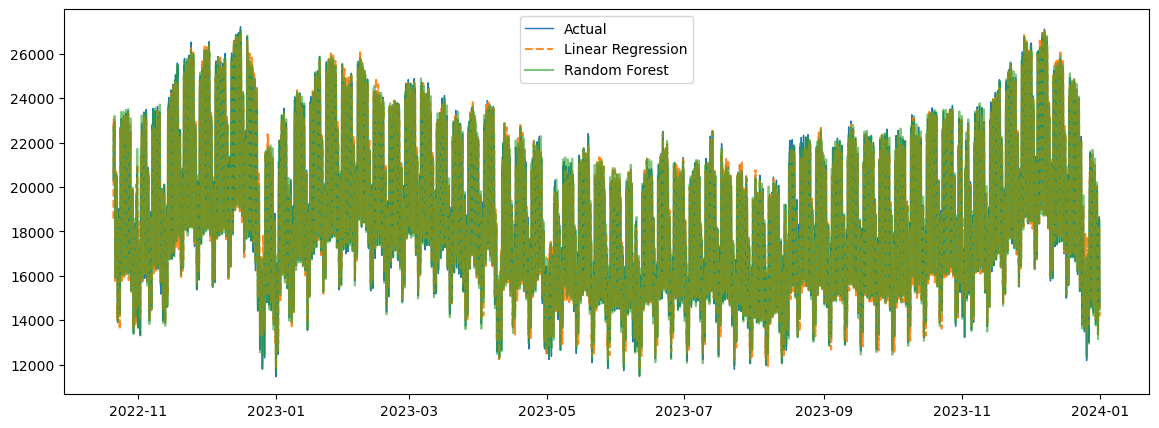

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

plt.plot(predictions_df["timestamp"], predictions_df["actual_load"], label="Actual", linewidth=1)

plt.plot(predictions_df["timestamp"], predictions_df["lr_pred"], 
         label="Linear Regression", alpha=0.9, linestyle="--")

plt.plot(predictions_df["timestamp"], predictions_df["rf_pred"], 
         label="Random Forest", alpha=0.6)

plt.legend()
plt.show()

In [27]:
results_df.to_csv("../data/processed/model_results_overall.csv", index=False)
period_results_df.to_csv("../data/processed/model_results_by_period.csv", index=False)
predictions_df.to_csv("../data/processed/model_predictions.csv", index=False)

print("Saved:")
print("- model_results_overall.csv")
print("- model_results_by_period.csv")
print("- model_predictions.csv")

Saved:
- model_results_overall.csv
- model_results_by_period.csv
- model_predictions.csv


In [28]:
predictions_df["period"].value_counts()

period
war    10483
Name: count, dtype: int64

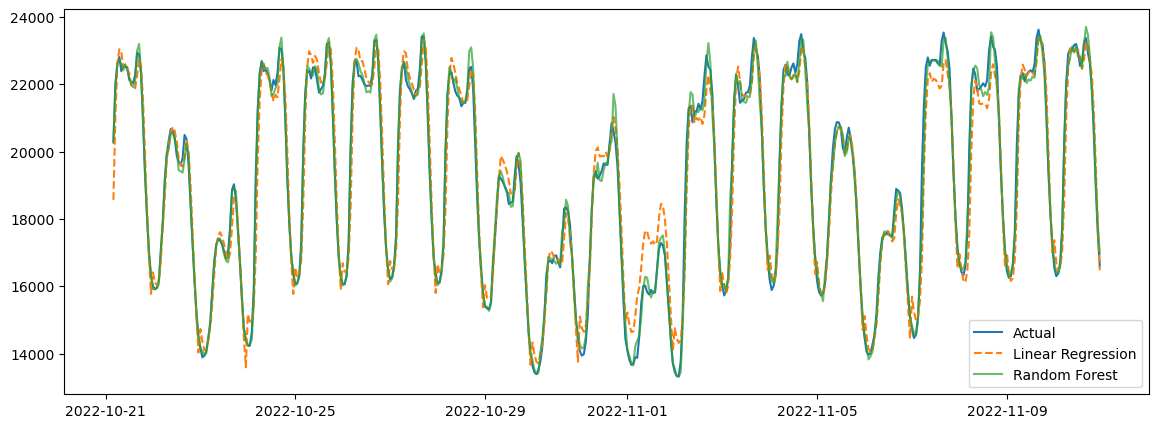

In [29]:
subset = predictions_df.iloc[:500]

plt.figure(figsize=(14, 5))
plt.plot(subset["timestamp"], subset["actual_load"], label="Actual")
plt.plot(subset["timestamp"], subset["lr_pred"], label="Linear Regression", linestyle="--")
plt.plot(subset["timestamp"], subset["rf_pred"], label="Random Forest", alpha=0.7)

plt.legend()
plt.show()

In [30]:
import joblib

joblib.dump(lr_model, "../data/processed/linear_regression_model_calm.pkl")
joblib.dump(rf_model, "../data/processed/random_forest_model_calm.pkl")
joblib.dump(dt_model, "../data/processed/decision_tree_model_calm.pkl")
joblib.dump(gb_model, "../data/processed/gradient_boosting_model_calm.pkl")
joblib.dump(knn_model, "../data/processed/knn_model_calm.pkl")
joblib.dump(svr_model, "../data/processed/svr_model_calm.pkl")

print("Models saved.")

Models saved.


In [31]:
predictions_df["period"].value_counts()

period
war    10483
Name: count, dtype: int64

In [32]:
for p in predictions_df["period"].unique():
    subset = predictions_df[predictions_df["period"] == p]
    
    print(p)
    print("LR:", mean_absolute_error(subset["actual_load"], subset["lr_pred"]))
    print("RF:", mean_absolute_error(subset["actual_load"], subset["rf_pred"]))

war
LR: 447.58968457973106
RF: 191.84891666507684
